# Kazakhstan Government Budget — EDA

Exploratory analysis of the [Kazakhstan Gov Budget dataset](https://www.kaggle.com/datasets/baidalinadilzhan/kazakhstan-gov-budget-data) (`budget.csv`, converted from the original `budget.parquet`).

## Imports

In [293]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

## Load the data

In [294]:
df = pd.read_csv('data/budget.csv')
df.head()

,id,year,budget_type,revenue,expenditure,budget_balance,revenue_category,expenditure_category,region,agency,budget_planned,budget_executed,execution_rate,program_code,program_name,subProgram_code,subProgram_name,amount
0,1,2024,республиканский,18500000000000,2.210000e+13,-3.600000e+12,налоги,образование,республиканский уровень,Министерство образования и науки РК,2800000000000,2650000000000,94.6,1,Развитие образования,001-1,Дошкольное и среднее образование,1200000000000
1,2,2024,республиканский,18500000000000,2.210000e+13,-3.600000e+12,налоги,здравоохранение,республиканский уровень,Министерство здравоохранения РК,2200000000000,2090000000000,95.0,2,Развитие здравоохранения,002-1,Первичная медико-санитарная помощь,950000000000
2,3,2024,местный,7200000000000,7.450000e+12,-2.500000e+11,налоги,социальная помощь,Алматы,Акимат г. Алматы,850000000000,820000000000,96.5,3,Социальная поддержка населения,003-1,Адресная социальная помощь,420000000000
3,4,2024,республиканский,18500000000000,2.210000e+13,-3.600000e+12,неналоговые,оборона,республиканский уровень,Министерство обороны РК,1800000000000,1750000000000,97.2,4,Обеспечение обороноспособности,004-1,Содержание вооруженных сил,1200000000000
4,5,2024,местный,4800000000000,4.950000e+12,-1.500000e+11,налоги,транспорт,Астана,Акимат г. Астана,650000000000,635000000000,97.7,5,Развитие транспортной инфраструктуры,005-1,Дорожное строительство,380000000000


## Make the big money columns readable (convert to billions)

The monetary columns are in tenge and run into the trillions. Convert them to **billions** (÷ 1e9) so the numbers are readable. `execution_rate` (a %) and the `*_code`/`year`/`id` identifiers are left alone.

In [295]:
money_cols = ['revenue', 'expenditure', 'budget_balance',
              'budget_planned', 'budget_executed', 'amount']
# millions version of amount (keeps tiny values visible) — computed BEFORE rounding to billions
df['amount_mln'] = (df['amount'] / 1e6).round(3)
df[money_cols] = (df[money_cols] / 1e9).round(2)
df = df.rename(columns={c: c + '_bln' for c in money_cols})
df.head()

,id,year,budget_type,revenue_bln,expenditure_bln,budget_balance_bln,revenue_category,expenditure_category,region,agency,budget_planned_bln,budget_executed_bln,execution_rate,program_code,program_name,subProgram_code,subProgram_name,amount_bln,amount_mln
0,1,2024,республиканский,18500.0,22100.0,-3600.0,налоги,образование,республиканский уровень,Министерство образования и науки РК,2800.0,2650.0,94.6,1,Развитие образования,001-1,Дошкольное и среднее образование,1200.0,1200000.0
1,2,2024,республиканский,18500.0,22100.0,-3600.0,налоги,здравоохранение,республиканский уровень,Министерство здравоохранения РК,2200.0,2090.0,95.0,2,Развитие здравоохранения,002-1,Первичная медико-санитарная помощь,950.0,950000.0
2,3,2024,местный,7200.0,7450.0,-250.0,налоги,социальная помощь,Алматы,Акимат г. Алматы,850.0,820.0,96.5,3,Социальная поддержка населения,003-1,Адресная социальная помощь,420.0,420000.0
3,4,2024,республиканский,18500.0,22100.0,-3600.0,неналоговые,оборона,республиканский уровень,Министерство обороны РК,1800.0,1750.0,97.2,4,Обеспечение обороноспособности,004-1,Содержание вооруженных сил,1200.0,1200000.0
4,5,2024,местный,4800.0,4950.0,-150.0,налоги,транспорт,Астана,Акимат г. Астана,650.0,635.0,97.7,5,Развитие транспортной инфраструктуры,005-1,Дорожное строительство,380.0,380000.0


### Helpers (matplotlib / seaborn / numpy / pandas only)

In [296]:
def with_share(series, value_name='amount_bln', sort=True):
    # groupby Series -> DataFrame with an extra %-of-total column
    s = series.sort_values(ascending=False) if sort else series
    out = s.to_frame(value_name)
    out['share_%'] = (out[value_name] / out[value_name].sum() * 100).round(2)
    return out


def bar_single(series, n=10, which='top', title='', palette='crest',
               highlight=None, xlabel='Amount (bln tenge)'):
    # one horizontal bar chart of the top-N or bottom-N values, labelled with value + % of total
    total = series.sum()
    s = (series.nlargest(n) if which == 'top' else series.nsmallest(n)).sort_values()
    fig, ax = plt.subplots(figsize=(10, 0.5 * len(s) + 1.6))
    base = sns.color_palette(palette, len(s))
    colors = ['#e8743b' if (highlight and nm in highlight) else base[i] for i, nm in enumerate(s.index)]
    bars = ax.barh(s.index, s.values, color=colors)
    for b, v in zip(bars, s.values):
        ax.text(v, b.get_y() + b.get_height() / 2, f'  {v:,.2f} ({v / total * 100:.2f}%)',
                va='center', fontsize=9, color='#333')
    ax.set_title(title, fontweight='bold', fontsize=12); ax.set_xlabel(xlabel)
    sns.despine(left=True); ax.margins(x=0.28); plt.tight_layout(); plt.show()


def diverging_barh(series, n=12, title='',
                   xlabel='Executed - Planned (bln)   |   negative = under budget'):
    # zero-centred diverging horizontal bars (red < 0, green > 0)
    s = series.reindex(series.abs().sort_values(ascending=False).index).head(n).sort_values()
    colors = ['#d1495b' if v < 0 else '#2e8b57' for v in s.values]
    fig, ax = plt.subplots(figsize=(10, 0.5 * len(s) + 1.6))
    bars = ax.barh(s.index, s.values, color=colors)
    ax.axvline(0, color='black', lw=0.9)
    for b, v in zip(bars, s.values):
        ax.text(v, b.get_y() + b.get_height() / 2, f' {v:,.0f} ',
                va='center', ha='left' if v >= 0 else 'right', fontsize=8)
    ax.set_title(title, fontweight='bold', fontsize=12); ax.set_xlabel(xlabel)
    sns.despine(left=True); plt.tight_layout(); plt.show()


def _squarify(sizes, x, y, dx, dy):
    def layout(sz, x, y, dx, dy):
        cov = sum(sz); rects = []
        if dx >= dy:
            w = cov / dy; yy = y
            for s in sz:
                rects.append((x, yy, w, s / w)); yy += s / w
        else:
            h = cov / dx; xx = x
            for s in sz:
                rects.append((xx, y, s / h, h)); xx += s / h
        return rects
    def leftover(sz, x, y, dx, dy):
        cov = sum(sz)
        if dx >= dy:
            w = cov / dy; return x + w, y, dx - w, dy
        h = cov / dx; return x, y + h, dx, dy - h
    def worst(sz, x, y, dx, dy):
        return max(max(w / h, h / w) for (_, _, w, h) in layout(sz, x, y, dx, dy))
    sizes = list(map(float, sizes))
    if len(sizes) == 0: return []
    if len(sizes) == 1: return layout(sizes, x, y, dx, dy)
    i = 1
    while i < len(sizes) and worst(sizes[:i], x, y, dx, dy) >= worst(sizes[:i + 1], x, y, dx, dy):
        i += 1
    cur, rest = sizes[:i], sizes[i:]
    return layout(cur, x, y, dx, dy) + _squarify(rest, *leftover(cur, x, y, dx, dy))


def treemap(series, title='', palette='viridis', figsize=(12, 7), fmt='{:,.0f}'):
    series = series[series > 0].sort_values(ascending=False)
    norm = series.values * (100 * 100) / series.sum()
    rects = _squarify(norm, 0, 0, 100, 100)
    colors = sns.color_palette(palette, len(series))
    fig, ax = plt.subplots(figsize=figsize)
    for (x, y, w, h), name, val, col in zip(rects, series.index, series.values, colors):
        ax.add_patch(plt.Rectangle((x, y), w, h, color=col, ec='white', lw=2))
        if w * h > 22:
            ax.text(x + w / 2, y + h / 2, f'{name}\n' + fmt.format(val),
                    ha='center', va='center', fontsize=8, color='white')
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.invert_yaxis(); ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=12); plt.tight_layout(); plt.show()

In [297]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    615 non-null    int64  
 1   year                  615 non-null    int64  
 2   budget_type           615 non-null    object 
 3   revenue_bln           615 non-null    float64
 4   expenditure_bln       615 non-null    float64
 5   budget_balance_bln    615 non-null    float64
 6   revenue_category      615 non-null    object 
 7   expenditure_category  615 non-null    object 
 8   region                615 non-null    object 
 9   agency                615 non-null    object 
 10  budget_planned_bln    615 non-null    float64
 11  budget_executed_bln   615 non-null    float64
 12  execution_rate        615 non-null    float64
 13  program_code          615 non-null    int64  
 14  program_name          615 non-null    object 
 15  subProgram_code       6

In [298]:
df.describe()

,id,year,revenue_bln,expenditure_bln,budget_balance_bln,budget_planned_bln,budget_executed_bln,execution_rate,program_code,amount_bln,amount_mln
count,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,6.150000e+02
mean,308.000000,2024.313821,6674.824309,7885.722146,-1210.897789,201.085171,65.976667,62.280118,66.653659,112.785154,1.127854e+05
std,177.679487,0.577020,9063.997785,10761.878317,1714.077337,592.388166,262.078223,45.412201,68.679319,322.948991,3.229489e+05
min,1.000000,2022.000000,0.000000,0.000000,-4100.000000,0.000000,0.000000,0.000000,1.000000,0.000000,4.000000e-03
25%,154.500000,2024.000000,2.775000,2.710000,-3600.000000,1.820000,0.000000,0.000000,5.000000,0.900000,8.950000e+02
50%,308.000000,2024.000000,12.600000,12.200000,0.000000,8.700000,2.750000,94.400000,42.000000,4.300000,4.300000e+03
75%,461.500000,2025.000000,18500.000000,22100.000000,0.080000,69.000000,12.200000,98.800000,117.000000,42.000000,4.200000e+04
max,615.000000,2027.000000,25600.000000,28800.000000,0.550000,4200.000000,2650.000000,99.300000,237.000000,2100.000000,2.100000e+06


## Basic questions

**Which years are covered, and how many records per year?**

In [299]:
df['year'].value_counts().sort_index()

year
2022      2
2023     10
2024    411
2025    182
2026      5
2027      5
Name: count, dtype: int64

**What are the budget types (республиканский / местный) and their split?**

In [300]:
df['budget_type'].value_counts()

budget_type
республиканский    324
местный            291
Name: count, dtype: int64

**Total `amount` (billions) by expenditure category (top 10) — with share of total.**

In [301]:
with_share(df.groupby('expenditure_category')['amount_bln'].sum()).head(10)

,amount_bln,share_%
expenditure_category,,
образование,11832.04,17.06
здравоохранение,10105.97,14.57
оборона,9236.55,13.32
транспорт,7600.54,10.96
социальная помощь,6848.46,9.87
сельское хозяйство,1888.25,2.72
внутренние дела,1705.40,2.46
индустрия,1535.00,2.21
экономические вопросы,1420.00,2.05


**Total `amount` (billions) by region (top 10) — with share of total.**

In [302]:
with_share(df.groupby('region')['amount_bln'].sum()).head(10)

,amount_bln,share_%
region,,
республиканский уровень,59922.01,86.39
Алматы,1885.90,2.72
Астана,1792.55,2.58
Шымкент,1241.83,1.79
Карагандинская область,799.22,1.15
Восточно-Казахстанская область,428.07,0.62
Западно-Казахстанская область,378.67,0.55
Южно-Казахстанская область,323.28,0.47
Северо-Казахстанская область,300.48,0.43


> **What is `республиканский уровень`?** It is the **republican (national) level** — the central government's own budget (national ministries + country-wide programmes), as opposed to a region's *local* budget. It dominates (~86%) because all central-government spending is lumped under this one label, while each region only holds its smaller local share. It is not really a region. (See Q9: the republican budget is ~87% of the total.)

### Q1 — Which sector has the biggest share? Is education or healthcare funded more?

In [303]:
sector = with_share(df.groupby('expenditure_category')['amount_bln'].sum())
print('Biggest sector overall:', sector.index[0], '=', sector.iloc[0]['amount_bln'], 'bln (', sector.iloc[0]['share_%'], '% of total )')
print()
print('Education vs Healthcare:')
sector.loc[['образование', 'здравоохранение']]

Biggest sector overall: образование = 11832.04 bln ( 17.06 % of total )

Education vs Healthcare:


,amount_bln,share_%
expenditure_category,,
образование,11832.04,17.06
здравоохранение,10105.97,14.57


##### Chart — top 10 sectors (education & healthcare highlighted)

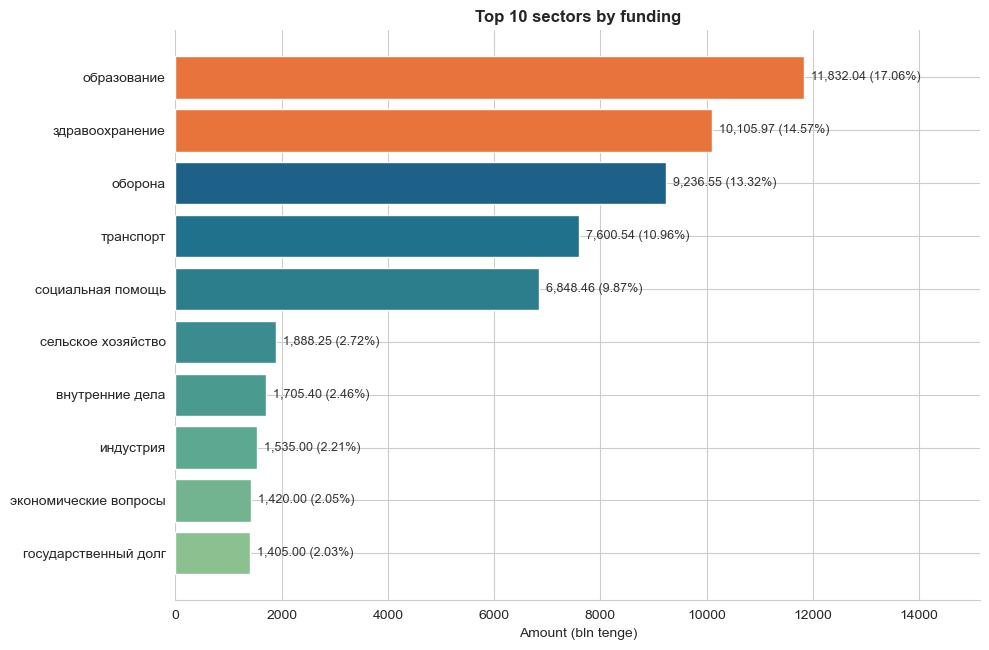

In [304]:
bar_single(df.groupby('expenditure_category')['amount_bln'].sum(), 10, 'top',
           'Top 10 sectors by funding', palette='crest',
           highlight={'образование', 'здравоохранение'})

##### Chart — bottom 10 sectors (shown in millions, non-zero only)

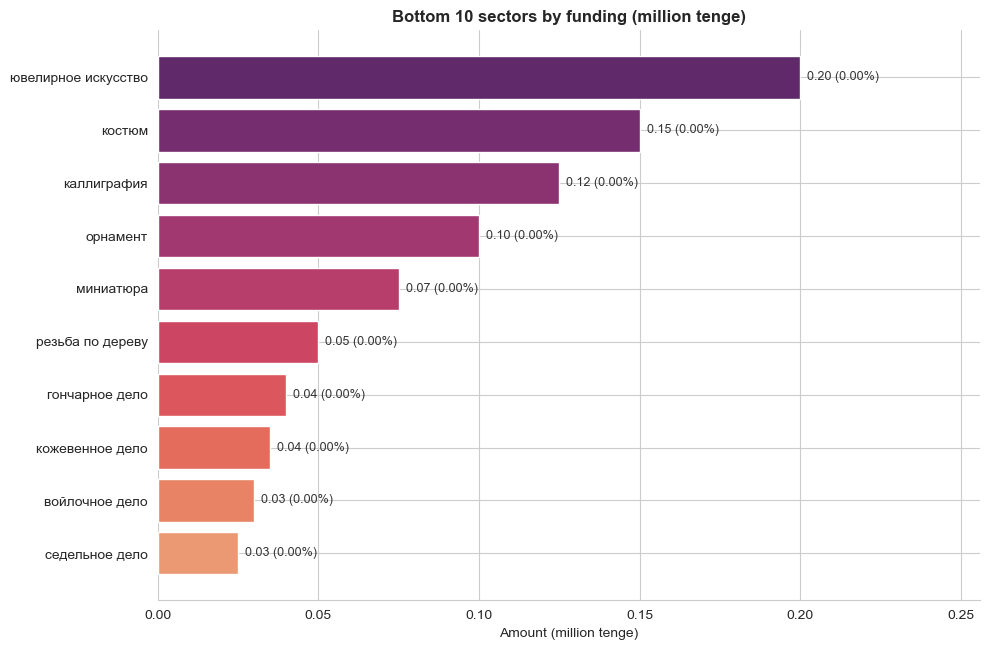

In [305]:
# small sectors are sub-billion, so show them in MILLIONS (nonzero) instead of billions
s = df.groupby('expenditure_category')['amount_mln'].sum()
bar_single(s[s > 0], 10, 'bottom', 'Bottom 10 sectors by funding (million tenge)',
           palette='flare', xlabel='Amount (million tenge)')

### Q2 — Which regions receive the most, and which the least?

In [306]:
region = with_share(df.groupby('region')['amount_bln'].sum())
print('MOST funded regions:')
print(region.head(5))
print()
print('LEAST funded regions:')
print(region.tail(5))

MOST funded regions:
                         amount_bln  share_%
region                                      
республиканский уровень    59922.01    86.39
Алматы                      1885.90     2.72
Астана                      1792.55     2.58
Шымкент                     1241.83     1.79
Карагандинская область       799.22     1.15

LEAST funded regions:
                     amount_bln  share_%
region                                  
Улытау                    110.6     0.16
Абай                      102.3     0.15
Жетісу                     93.0     0.13
вся территория             70.6     0.10
Алматинская область        10.3     0.01


##### Chart — most funded regions

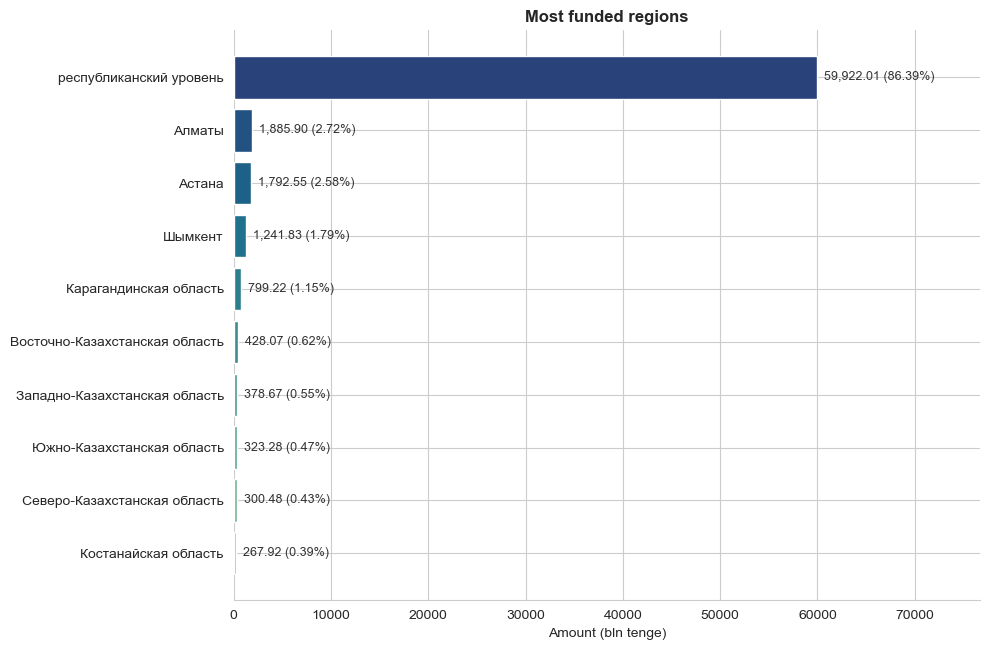

In [307]:
bar_single(df.groupby('region')['amount_bln'].sum(), 10, 'top', 'Most funded regions', palette='crest')

##### Chart — most funded regions, EXCLUDING the national level
(the national level dominates the chart above, so here it is removed to compare actual regions)

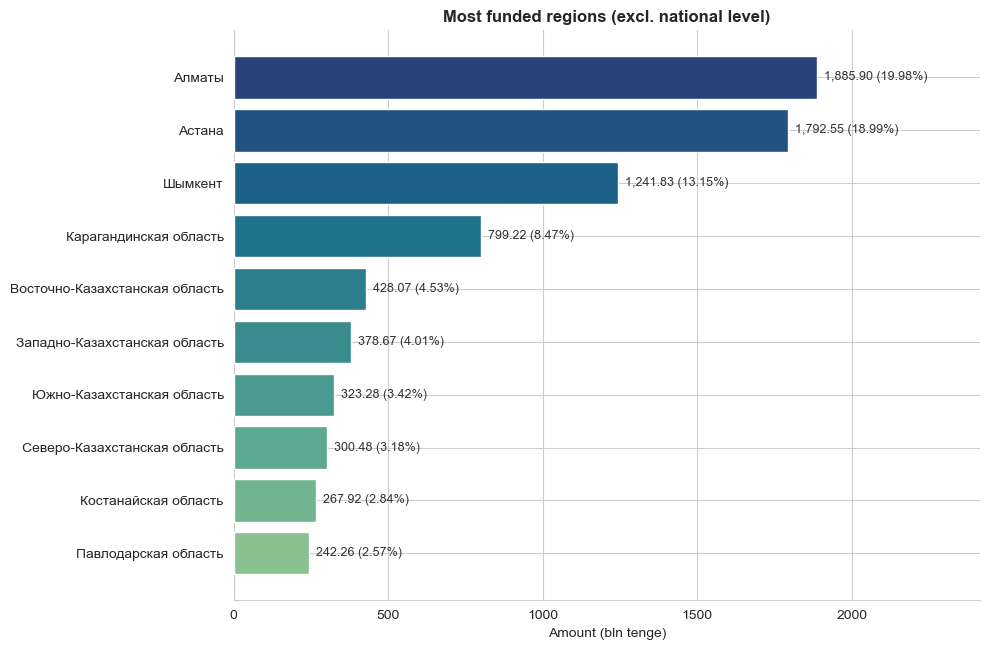

In [308]:
reg_excl = df[df['region'] != 'республиканский уровень'].groupby('region')['amount_bln'].sum()
bar_single(reg_excl, 10, 'top', 'Most funded regions (excl. national level)', palette='crest')

##### Chart — least funded regions

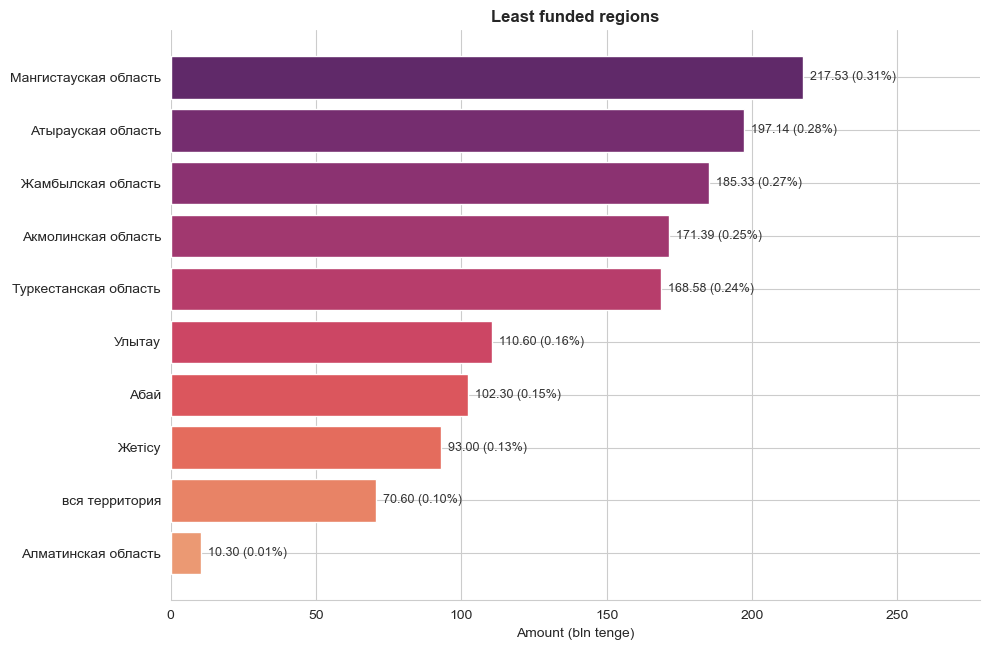

In [309]:
bar_single(df.groupby('region')['amount_bln'].sum(), 10, 'bottom', 'Least funded regions', palette='flare')

### Q3 — Do the big 3 cities (Astana, Almaty, Shymkent) receive more?

In [310]:
big3 = ['Астана', 'Алматы', 'Шымкент']
is_big3 = df['region'].isin(big3)
total = df['amount_bln'].sum()
b3 = df.loc[is_big3, 'amount_bln'].sum()
print(f'Big-3 cities: {round(b3, 1)} bln = {round(b3 / total * 100, 2)}% of total')
print('Average amount per record:')
print(df.groupby(is_big3)['amount_bln'].mean().rename({False: 'other regions', True: 'big-3 cities'}))

Big-3 cities: 4920.3 bln = 7.09% of total
Average amount per record:
region
other regions    108.125151
big-3 cities     258.962105
Name: amount_bln, dtype: float64


##### Chart — mean amount per record: big-3 cities vs others

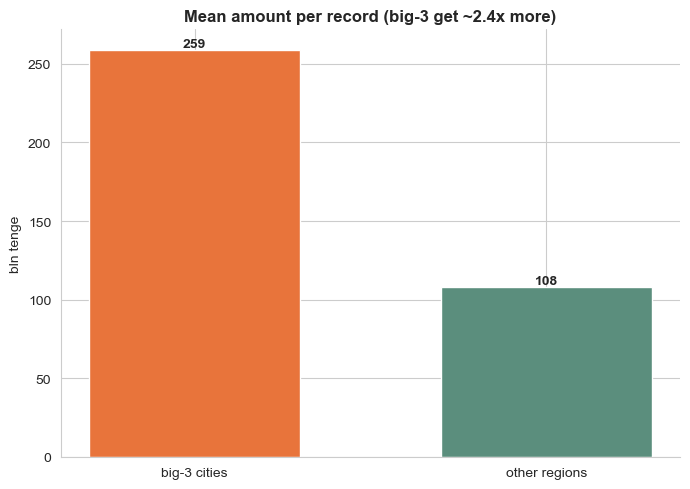

In [311]:
big3 = ['Астана', 'Алматы', 'Шымкент']
grp = np.where(df['region'].isin(big3), 'big-3 cities', 'other regions')
means = df.groupby(grp)['amount_bln'].mean().reindex(['big-3 cities', 'other regions'])
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(means.index, means.values, color=['#e8743b', '#5b8e7d'], width=0.6)
for b, v in zip(bars, means.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')
ratio = means['big-3 cities'] / means['other regions']
ax.set_ylabel('bln tenge')
ax.set_title(f'Mean amount per record (big-3 get ~{ratio:.1f}x more)', fontweight='bold')
sns.despine(); plt.tight_layout(); plt.show()

##### Chart — total funding per big-3 city

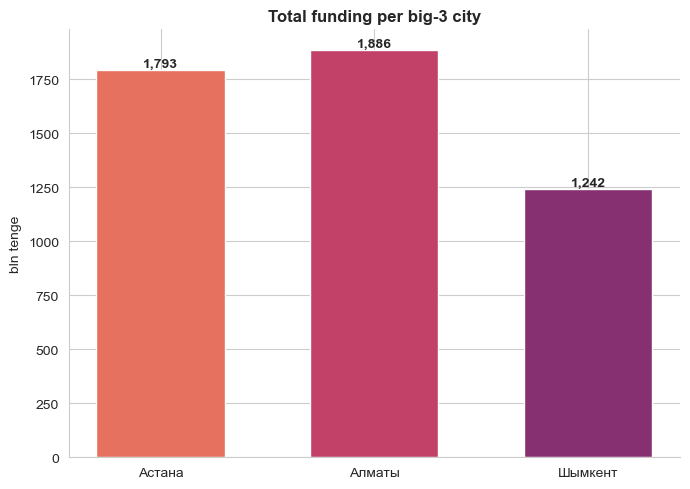

In [312]:
big3 = ['Астана', 'Алматы', 'Шымкент']
city = df[df['region'].isin(big3)].groupby('region')['amount_bln'].sum().reindex(big3)
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(city.index, city.values, color=sns.color_palette('flare', 3), width=0.6)
for b, v in zip(bars, city.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('bln tenge'); ax.set_title('Total funding per big-3 city', fontweight='bold')
sns.despine(); plt.tight_layout(); plt.show()

### Q4 — Which ministries (agencies) have the largest budget?

In [313]:
with_share(df.groupby('agency')['amount_bln'].sum()).head(10)

,amount_bln,share_%
agency,,
Министерство обороны РК,9708.55,14.00
Министерство здравоохранения РК,8954.00,12.91
Министерство индустрии и инфраструктурного развития РК,7545.58,10.88
Министерство просвещения РК,5796.97,8.36
Министерство труда и социальной защиты населения РК,5245.77,7.56
Министерство образования и науки РК,4695.05,6.77
Министерство национальной экономики РК,2502.35,3.61
Министерство цифрового развития РК,2194.00,3.16
Министерство сельского хозяйства РК,1942.96,2.80


##### Chart — top 10 ministries

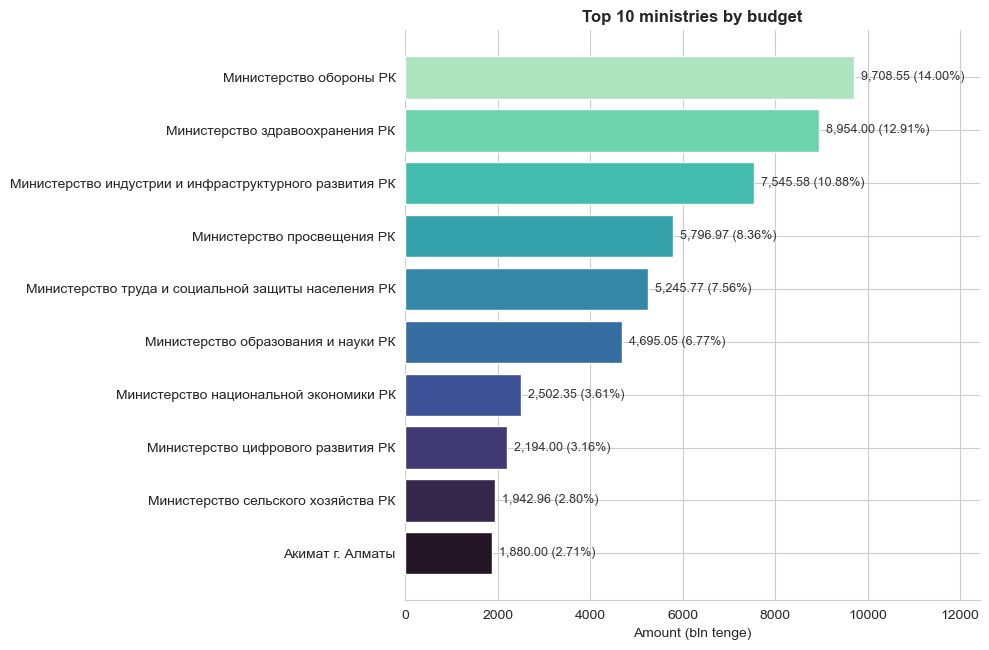

In [314]:
bar_single(df.groupby('agency')['amount_bln'].sum(), 10, 'top', 'Top 10 ministries by budget', palette='mako')

In [315]:
with_share(df.groupby('agency')['amount_bln'].sum()).tail(10)

,amount_bln,share_%
agency,,
Морские метеостанции области Жетісу,0.0,0.0
Минералогические коллекции Павлодарской области,0.0,0.0
Метеостанции здравоохранения Мангистауской области,0.0,0.0
Лимнологические исследования Акмолинской области,0.0,0.0
Авиационные метеостанции области Абай,0.0,0.0
Радиометеорологические службы Павлодарской области,0.0,0.0
Климатические станции транспорта области Жетісу,0.0,0.0
Картографические службы транспорта Жамбылской области,0.0,0.0
Картографические кружки Туркестанской области,0.0,0.0


##### Chart — bottom 10 ministries (shown in millions, non-zero only)

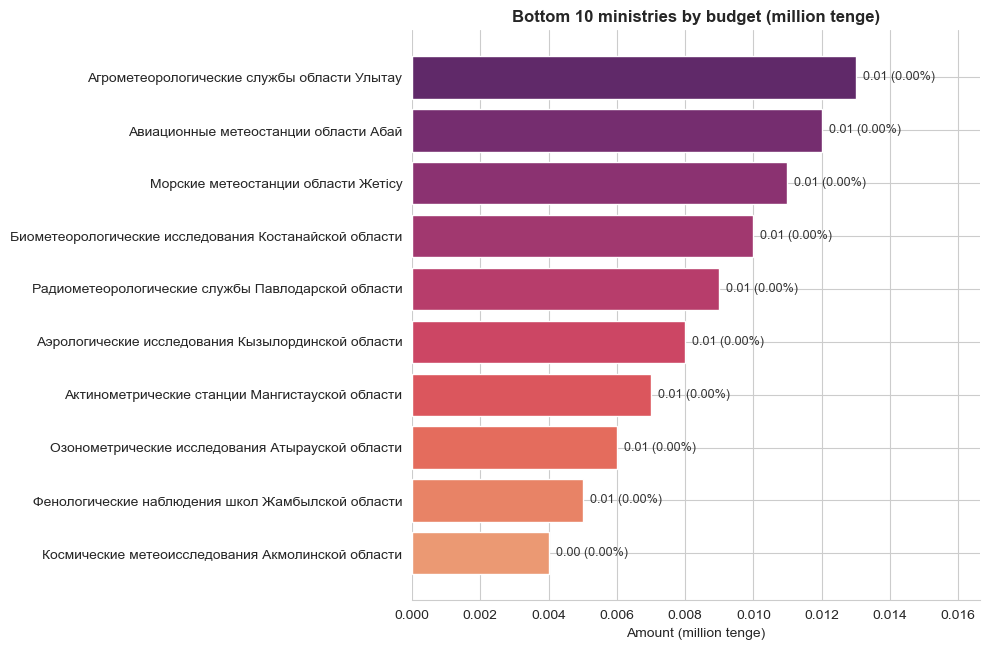

In [316]:
# small ministries are sub-billion, so show them in MILLIONS (nonzero only)
s = df.groupby('agency')['amount_mln'].sum()
bar_single(s[s > 0], 10, 'bottom', 'Bottom 10 ministries by budget (million tenge)',
           palette='flare', xlabel='Amount (million tenge)')

### Q5 — How much comes from taxes vs non-tax revenue? Why?
Taxes (`налоги`) are the main, stable source; non-tax income (`неналоговые` — dividends, National Fund transfers, fines) is smaller and more volatile.

In [317]:
with_share(df.groupby('revenue_category')['amount_bln'].sum())

,amount_bln,share_%
revenue_category,,
налоги,51979.27,74.94
неналоговые,17383.60,25.06


##### Chart — revenue composition (stacked)

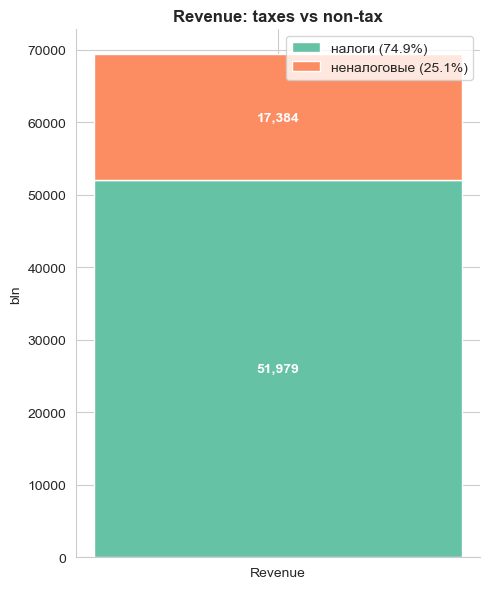

In [318]:
rev = df.groupby('revenue_category')['amount_bln'].sum(); total = rev.sum()
fig, ax = plt.subplots(figsize=(5, 6)); bottom = 0
for (cat, val), c in zip(rev.items(), sns.color_palette('Set2', len(rev))):
    ax.bar('Revenue', val, bottom=bottom, color=c, width=0.5, label=f'{cat} ({val / total * 100:.1f}%)')
    ax.text(0, bottom + val / 2, f'{val:,.0f}', ha='center', va='center', color='white', fontweight='bold'); bottom += val
ax.set_ylabel('bln'); ax.set_title('Revenue: taxes vs non-tax', fontweight='bold'); ax.legend(); sns.despine(); plt.tight_layout(); plt.show()

### Q6 — Gap between planned and executed budget

In [319]:
df['gap_bln'] = df['budget_planned_bln'] - df['budget_executed_bln']
print('Total gap (planned - executed):', round(df['gap_bln'].sum(), 1), 'bln')

Total gap (planned - executed): 83091.7 bln


##### Chart — executed vs planned by category (diverging)

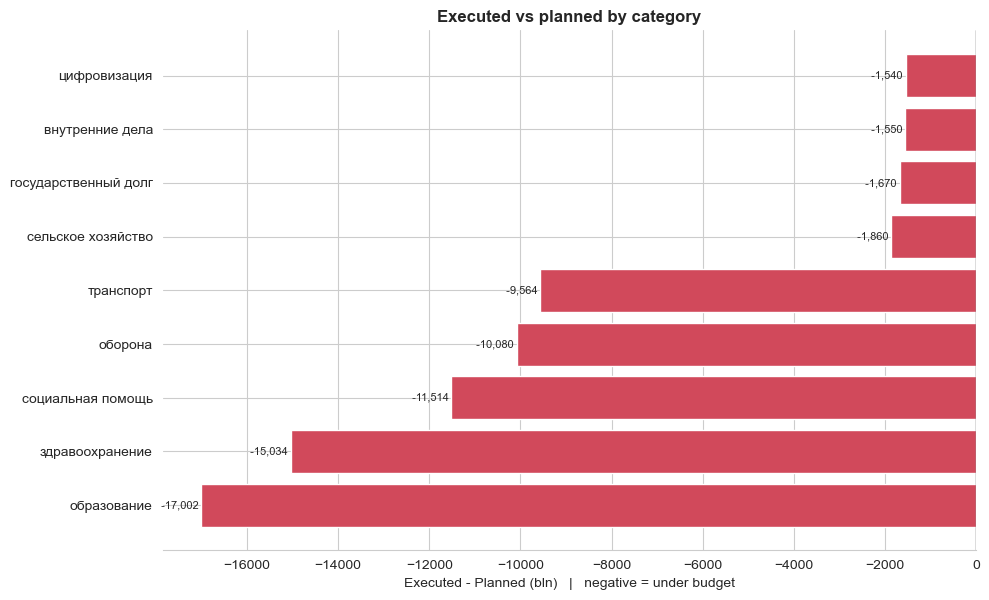

In [320]:
diverging_barh(-df.groupby('expenditure_category')['gap_bln'].sum(), 9, 'Executed vs planned by category')

**Q6a — Gap by region**

In [321]:
with_share(df.groupby('region')['gap_bln'].sum(), 'gap_bln').head(10)

,gap_bln,share_%
region,,
республиканский уровень,73545.15,88.51
Алматы,2200.18,2.65
Астана,1725.10,2.08
Шымкент,1340.04,1.61
Карагандинская область,888.06,1.07
Восточно-Казахстанская область,433.11,0.52
Западно-Казахстанская область,375.16,0.45
Южно-Казахстанская область,327.97,0.39
Северо-Казахстанская область,290.14,0.35


##### Chart — gap by region (diverging)

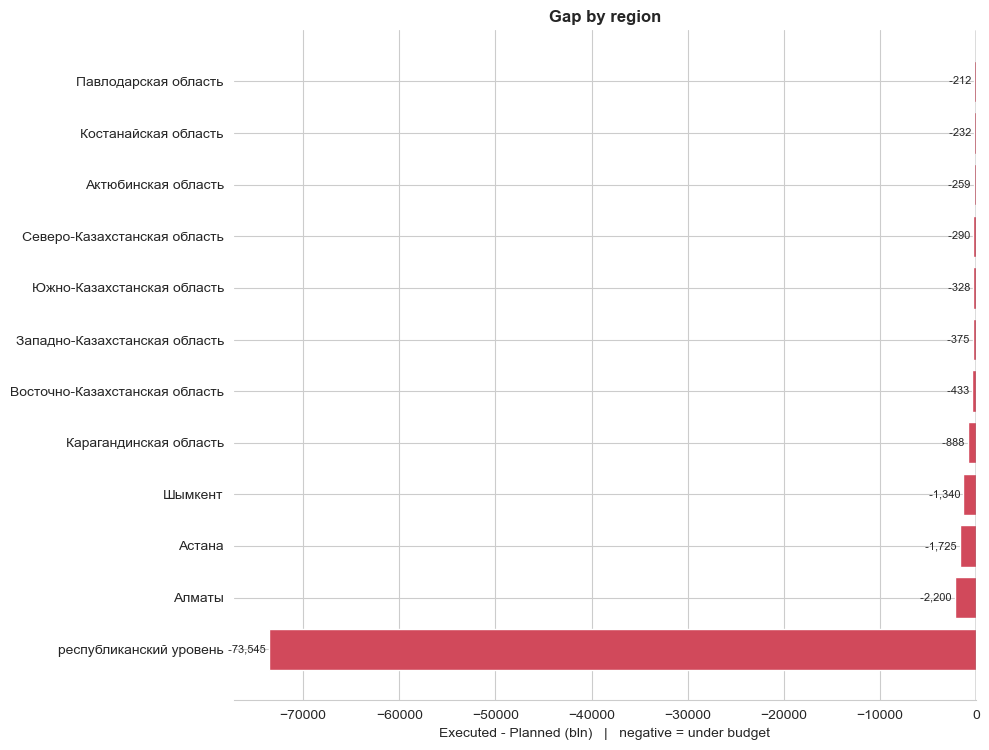

In [322]:
diverging_barh(-df.groupby('region')['gap_bln'].sum(), 12, 'Gap by region')

##### Chart — gap by region, EXCLUDING the national level

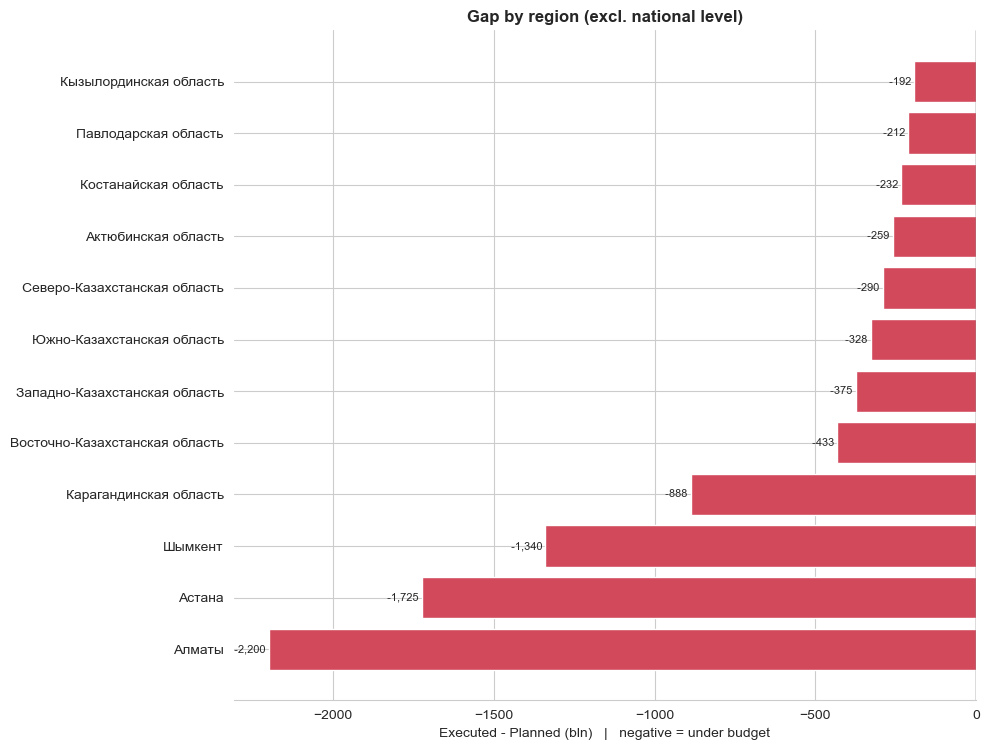

In [323]:
diverging_barh(-df[df['region'] != 'республиканский уровень'].groupby('region')['gap_bln'].sum(), 12,
               'Gap by region (excl. national level)')

**Q6b — Gap by ministry**

In [324]:
with_share(df.groupby('agency')['gap_bln'].sum(), 'gap_bln').head(10)

,gap_bln,share_%
agency,,
Министерство здравоохранения РК,13485.53,16.23
Министерство просвещения РК,11550.49,13.90
Министерство обороны РК,10514.10,12.65
Министерство труда и социальной защиты населения РК,10150.87,12.22
Министерство индустрии и инфраструктурного развития РК,9252.90,11.14
Министерство образования и науки РК,3520.50,4.24
Министерство национальной экономики РК,2260.30,2.72
Акимат г. Алматы,2200.00,2.65
Министерство финансов РК,2000.19,2.41


##### Chart — gap by ministry (diverging)

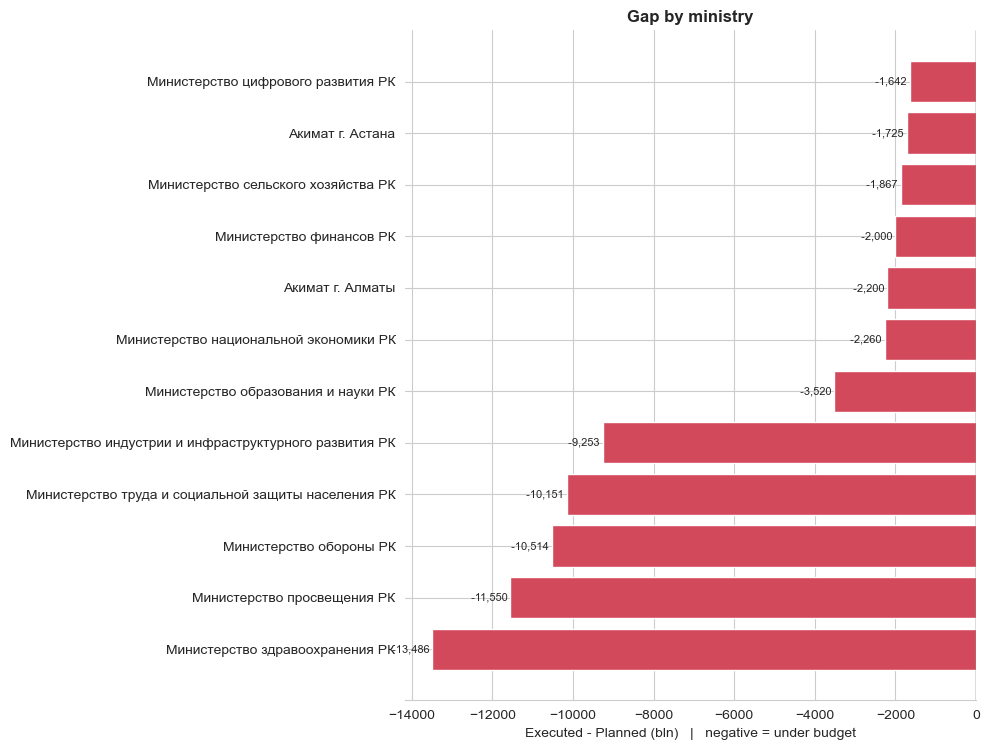

In [325]:
diverging_barh(-df.groupby('agency')['gap_bln'].sum(), 12, 'Gap by ministry')

### Q7 — Which sectors execute their budget best, and which underperform?
(mean execution rate, excluding 0% rows)

In [326]:
sector_exec = (df[df['execution_rate'] > 0].groupby('expenditure_category')['execution_rate'].mean().sort_values())
print('BEST executing sectors:'); print(sector_exec.head(5))
print(); print('UNDERPERFORMING sectors:'); print(sector_exec.tail(5))

BEST executing sectors:
expenditure_category
мультимедиа       0.00004
видеоискусство    0.00007
киноклубы         0.00010
кинофестивали     0.00020
киноархивы        0.00030
Name: execution_rate, dtype: float64

UNDERPERFORMING sectors:
expenditure_category
метеорология           99.2
материнский капитал    99.2
зеленые технологии     99.2
резерв                 99.3
финансы                99.3
Name: execution_rate, dtype: float64


##### Chart — worst vs best sectors by execution rate

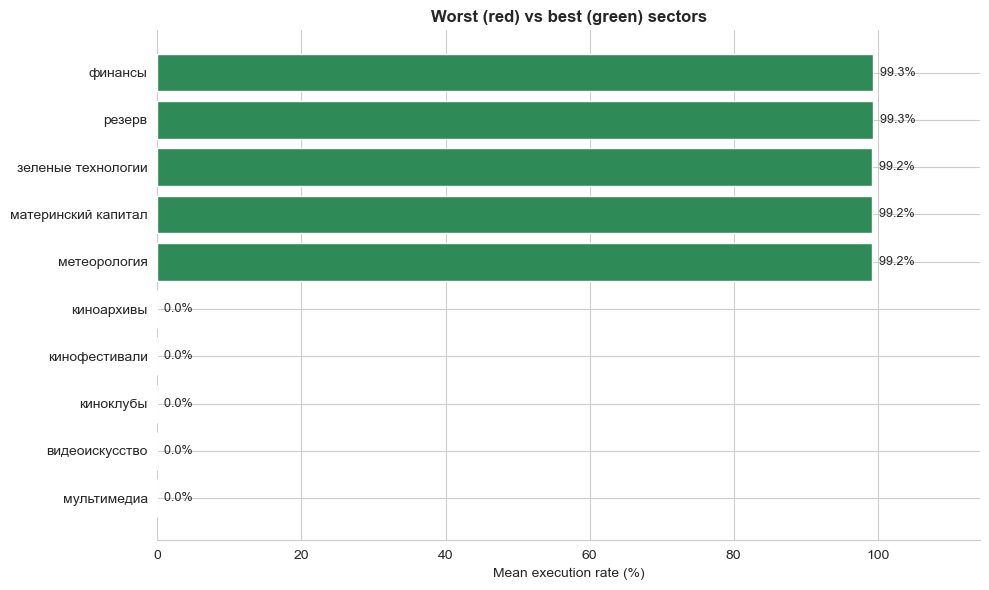

In [327]:
ex = df[df['execution_rate'] > 0].groupby('expenditure_category')['execution_rate'].mean().sort_values()
sel = pd.concat([ex.head(5), ex.tail(5)]); colors = ['#d1495b'] * 5 + ['#2e8b57'] * 5
fig, ax = plt.subplots(figsize=(10, 6)); bars = ax.barh(sel.index, sel.values, color=colors)
for b, v in zip(bars, sel.values):
    ax.text(v, b.get_y() + b.get_height() / 2, f'  {v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Mean execution rate (%)'); ax.set_title('Worst (red) vs best (green) sectors', fontweight='bold')
sns.despine(left=True); ax.margins(x=0.15); plt.tight_layout(); plt.show()

### Q8 — Where does Kazakhstan spend the most?
(top spending areas with % share of total)

In [328]:
with_share(df.groupby('expenditure_category')['amount_bln'].sum()).head(10)

,amount_bln,share_%
expenditure_category,,
образование,11832.04,17.06
здравоохранение,10105.97,14.57
оборона,9236.55,13.32
транспорт,7600.54,10.96
социальная помощь,6848.46,9.87
сельское хозяйство,1888.25,2.72
внутренние дела,1705.40,2.46
индустрия,1535.00,2.21
экономические вопросы,1420.00,2.05


##### Chart — treemap of the top 12 spending sectors

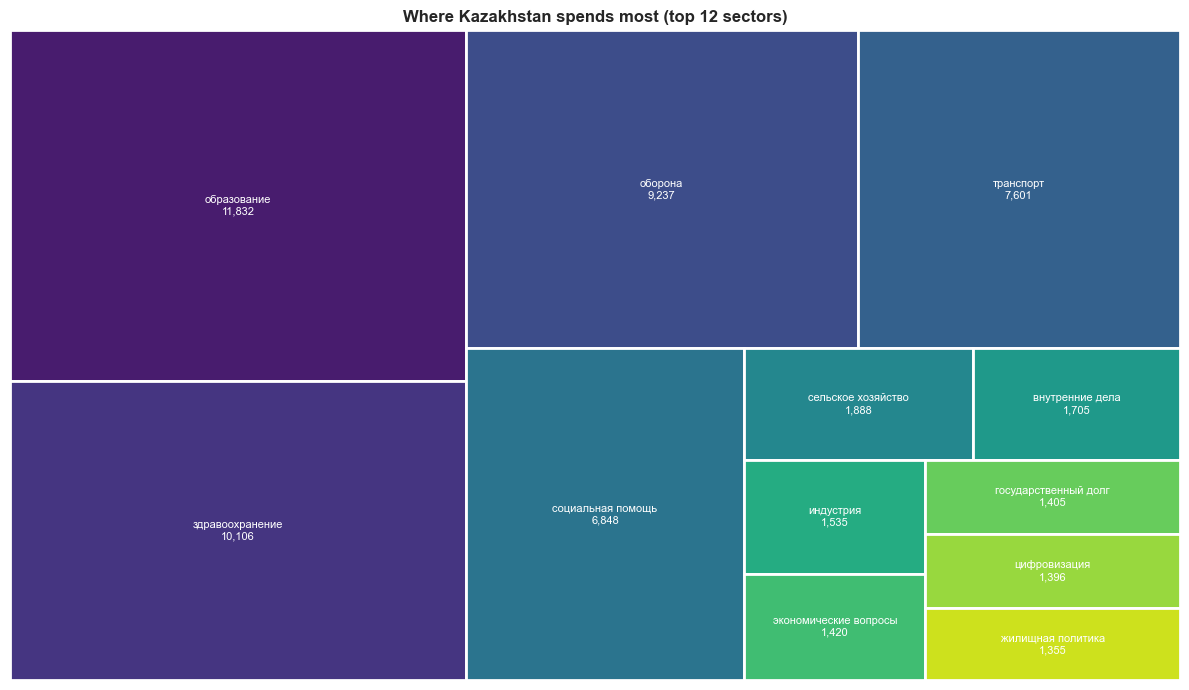

In [329]:
treemap(df.groupby('expenditure_category')['amount_bln'].sum().nlargest(12), 'Where Kazakhstan spends most (top 12 sectors)')

##### Chart — treemap of the smallest 12 spending sectors (in millions)

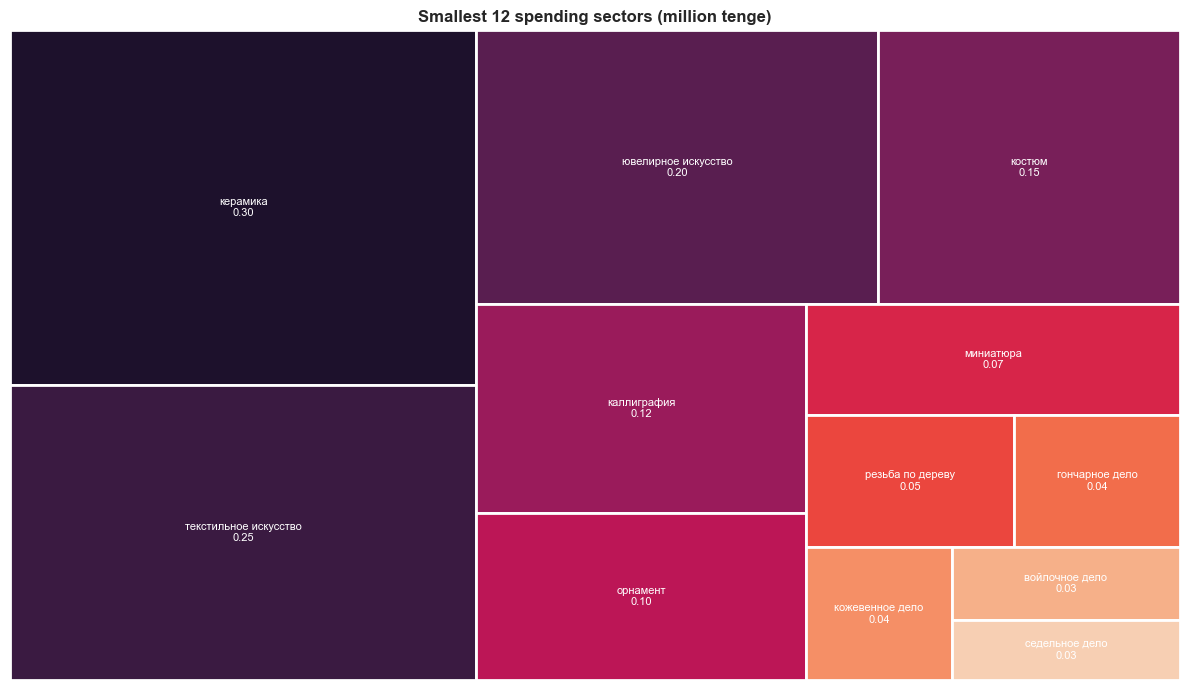

In [330]:
# smallest sectors are tiny in billions, so use MILLIONS so the treemap renders
s = df.groupby('expenditure_category')['amount_mln'].sum()
treemap(s[s > 0].nsmallest(12), 'Smallest 12 spending sectors (million tenge)',
        palette='rocket', fmt='{:,.2f}')

### Q9 — Local vs republican budget — which is bigger / more important?

In [331]:
with_share(df.groupby('budget_type')['amount_bln'].sum())

,amount_bln,share_%
budget_type,,
республиканский,60493.16,87.21
местный,8869.71,12.79


##### Chart — local vs republican (stacked)

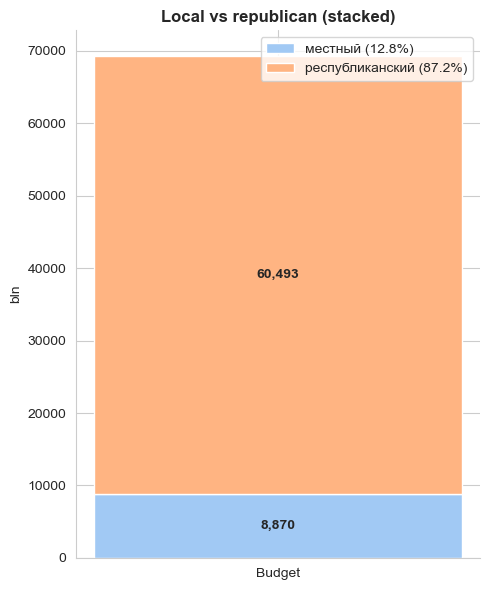

In [332]:
bt = df.groupby('budget_type')['amount_bln'].sum(); total = bt.sum()
fig, ax = plt.subplots(figsize=(5, 6)); bottom = 0
for (t, val), c in zip(bt.items(), sns.color_palette('pastel', len(bt))):
    ax.bar('Budget', val, bottom=bottom, color=c, width=0.5, label=f'{t} ({val / total * 100:.1f}%)')
    ax.text(0, bottom + val / 2, f'{val:,.0f}', ha='center', va='center', fontweight='bold'); bottom += val
ax.set_ylabel('bln'); ax.set_title('Local vs republican (stacked)', fontweight='bold'); ax.legend(); sns.despine(); plt.tight_layout(); plt.show()

### Q10 — Top and bottom records by execution rate (nonzero values only)

In [333]:
nz = df[df['execution_rate'] > 0]
cols = ['agency', 'expenditure_category', 'region', 'execution_rate']
from IPython.display import display
print('TOP 5 by execution rate:'); display(nz.nlargest(5, 'execution_rate')[cols])
print('BOTTOM 5 by execution rate (nonzero):'); display(nz.nsmallest(5, 'execution_rate')[cols])

TOP 5 by execution rate:


,agency,expenditure_category,region,execution_rate
382,Министерство образования и науки РК,образование,Астана,99.3
399,"Министерство цифрового развития, инноваций и а...",цифровизация,Алматы,99.3
400,Комитет ветеринарного контроля и надзора,ветеринария,Карагандинская область,99.3
402,Министерство финансов РК,финансы,вся территория,99.3
408,Комитет технического регулирования и метрологии,стандартизация,Павлодарская область,99.3


BOTTOM 5 by execution rate (nonzero):


,agency,expenditure_category,region,execution_rate
156,Службы по уборке Жамбылской области,жилищно-коммунальное хозяйство,Жамбылская область,0.000003
154,Паромные переправы Атырауской области,транспорт,Атырауская область,0.000006
152,Психологические службы Мангистауской области,социальная помощь,Мангистауская область,0.000010
150,Центры семейной медицины Кызылординской области,здравоохранение,Кызылординская область,0.000020
148,Центры дополнительного образования Павлодарско...,образование,Павлодарская область,0.000040


##### Chart — top 5 records by execution rate

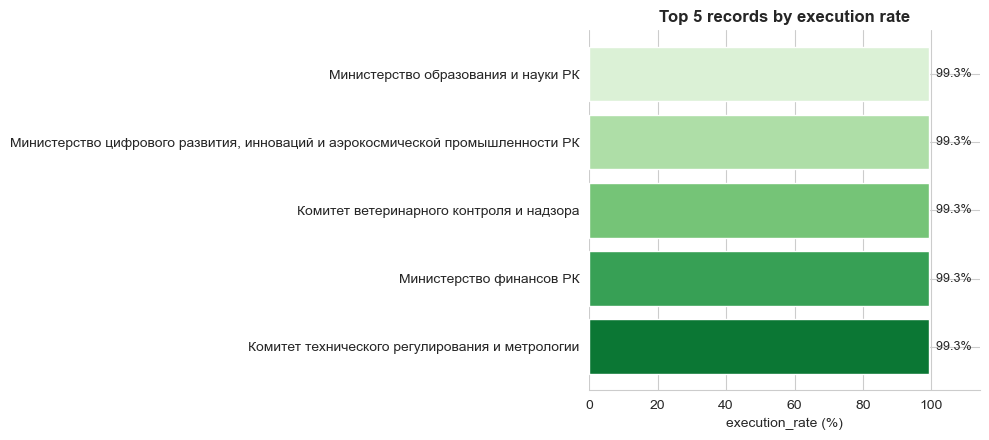

In [334]:
nz = df[df['execution_rate'] > 0]; top = nz.nlargest(5, 'execution_rate')
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(top['agency'][::-1], top['execution_rate'][::-1], color=sns.color_palette('Greens_r', 5))
for b, v in zip(bars, top['execution_rate'][::-1]):
    ax.text(v, b.get_y() + b.get_height() / 2, f'  {v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('execution_rate (%)'); ax.set_title('Top 5 records by execution rate', fontweight='bold')
sns.despine(left=True); ax.margins(x=0.15); plt.tight_layout(); plt.show()

##### Chart — bottom 5 records by execution rate (rates near 0)

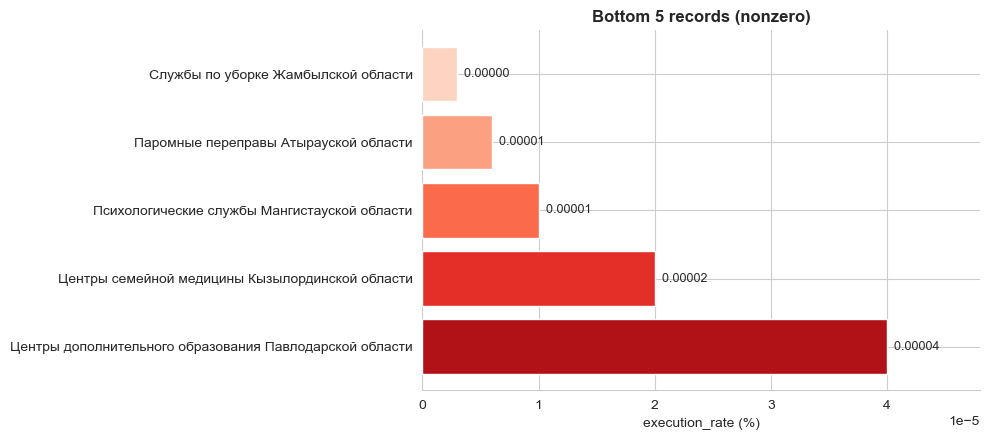

In [335]:
nz = df[df['execution_rate'] > 0]; bot = nz.nsmallest(5, 'execution_rate')
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(bot['agency'][::-1], bot['execution_rate'][::-1], color=sns.color_palette('Reds_r', 5))
for b, v in zip(bars, bot['execution_rate'][::-1]):
    ax.text(v, b.get_y() + b.get_height() / 2, f'  {v:.5f}', va='center', fontsize=9)
ax.set_xlabel('execution_rate (%)'); ax.set_title('Bottom 5 records (nonzero)', fontweight='bold')
sns.despine(left=True); ax.margins(x=0.2); plt.tight_layout(); plt.show()

### Q11 — Revenue vs expenditure: which budgets are more 'expensive' than income, which cheaper?
`budget_balance = revenue - expenditure`. Negative = deficit (spent more than earned); positive = surplus. These three columns are budget-level totals, so we use the **distinct budgets**.

In [336]:
budgets = df.drop_duplicates(subset=['revenue_bln', 'expenditure_bln', 'budget_balance_bln'])[['budget_type', 'region', 'revenue_bln', 'expenditure_bln', 'budget_balance_bln']].copy()
budgets['over_income_%'] = (-budgets['budget_balance_bln'] / budgets['revenue_bln'] * 100).round(1)
budgets = budgets.sort_values('budget_balance_bln')
from IPython.display import display
print('MOST expensive vs income (biggest deficits):'); display(budgets.head(5))
print('CHEAPEST vs income (smallest deficits):'); display(budgets.tail(5))

MOST expensive vs income (biggest deficits):


,budget_type,region,revenue_bln,expenditure_bln,budget_balance_bln,over_income_%
314,республиканский,республиканский уровень,21700.0,25800.0,-4100.0,18.9
0,республиканский,республиканский уровень,18500.0,22100.0,-3600.0,19.5
205,республиканский,республиканский уровень,21200.0,24800.0,-3600.0,17.0
360,республиканский,республиканский уровень,23800.0,27200.0,-3400.0,14.3
365,республиканский,республиканский уровень,25600.0,28800.0,-3200.0,12.5


CHEAPEST vs income (smallest deficits):


,budget_type,region,revenue_bln,expenditure_bln,budget_balance_bln,over_income_%
422,республиканский,вся территория,11.30,10.9,0.40,-3.5
606,республиканский,Южно-Казахстанская область,12.00,11.6,0.40,-3.3
382,республиканский,Астана,15.60,15.1,0.50,-3.2
380,республиканский,Западно-Казахстанская область,12.30,11.8,0.50,-4.1
378,республиканский,Алматинская область,8.75,8.2,0.55,-6.3


##### Chart — heatmap: deficit as % of revenue (region × budget type)

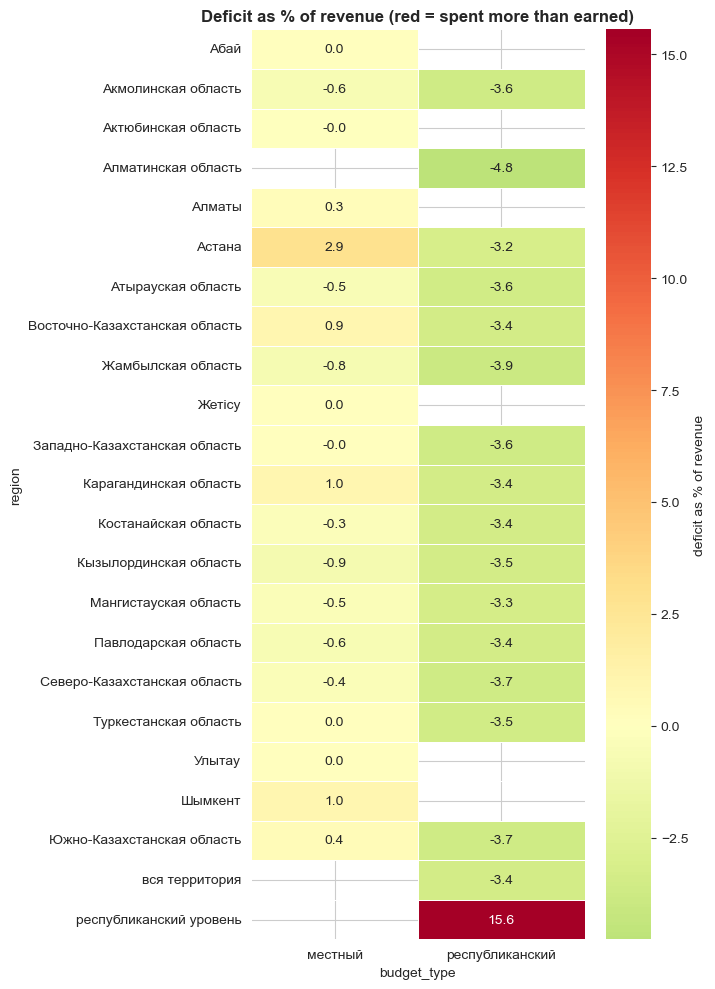

In [337]:
budgets = df.drop_duplicates(subset=['revenue_bln', 'expenditure_bln', 'budget_balance_bln']).copy()
budgets['over_income_%'] = -budgets['budget_balance_bln'] / budgets['revenue_bln'] * 100
piv = budgets.pivot_table(index='region', columns='budget_type', values='over_income_%', aggfunc='mean')
fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(piv, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0, linewidths=0.5, cbar_kws={'label': 'deficit as % of revenue'}, ax=ax)
ax.set_title('Deficit as % of revenue (red = spent more than earned)', fontweight='bold'); plt.tight_layout(); plt.show()

##### Chart — same heatmap, EXCLUDING the national level row

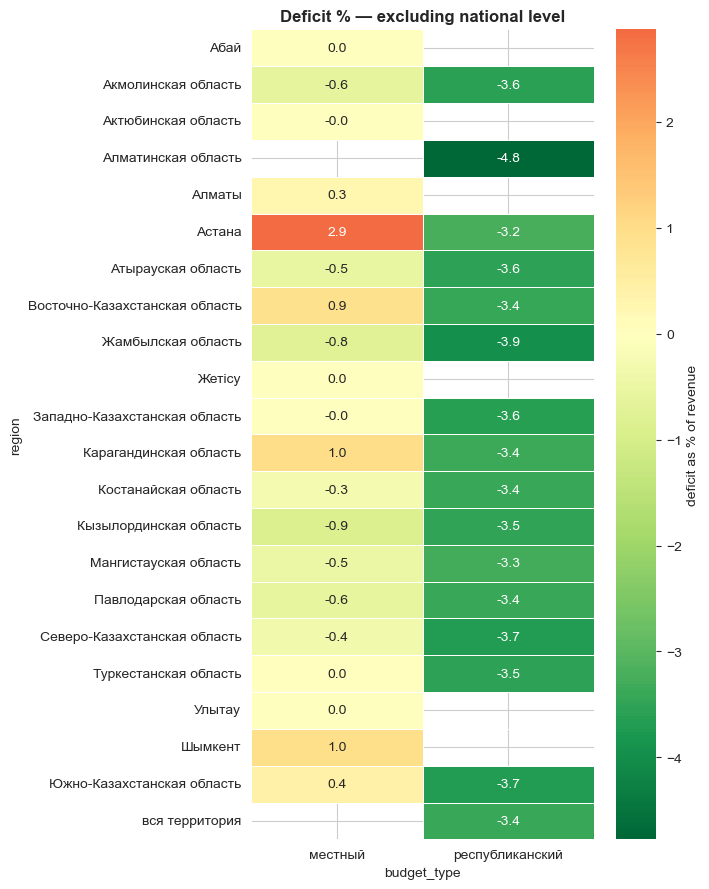

In [338]:
b2 = df[df['region'] != 'республиканский уровень'].drop_duplicates(subset=['revenue_bln', 'expenditure_bln', 'budget_balance_bln']).copy()
b2['over_income_%'] = -b2['budget_balance_bln'] / b2['revenue_bln'] * 100
piv2 = b2.pivot_table(index='region', columns='budget_type', values='over_income_%', aggfunc='mean')
fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(piv2, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0, linewidths=0.5, cbar_kws={'label': 'deficit as % of revenue'}, ax=ax)
ax.set_title('Deficit % — excluding national level', fontweight='bold'); plt.tight_layout(); plt.show()

## Extra insights

##### Chart — distribution of execution rate

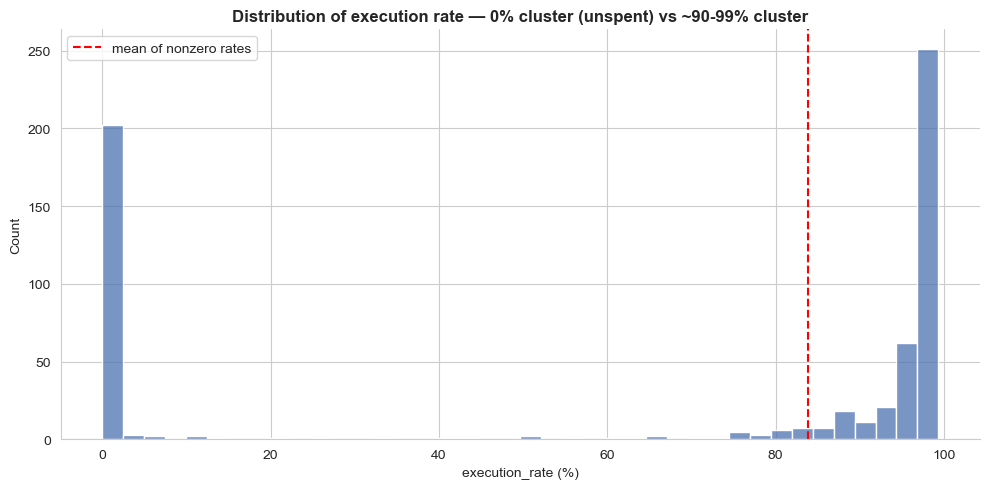

In [339]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['execution_rate'], bins=40, color='#4c72b0', ax=ax)
ax.axvline(df[df['execution_rate'] > 0]['execution_rate'].mean(), color='red', ls='--', label='mean of nonzero rates')
ax.set_title('Distribution of execution rate — 0% cluster (unspent) vs ~90-99% cluster', fontweight='bold')
ax.set_xlabel('execution_rate (%)'); ax.legend(); sns.despine(); plt.tight_layout(); plt.show()

##### Chart — do larger planned budgets execute better?

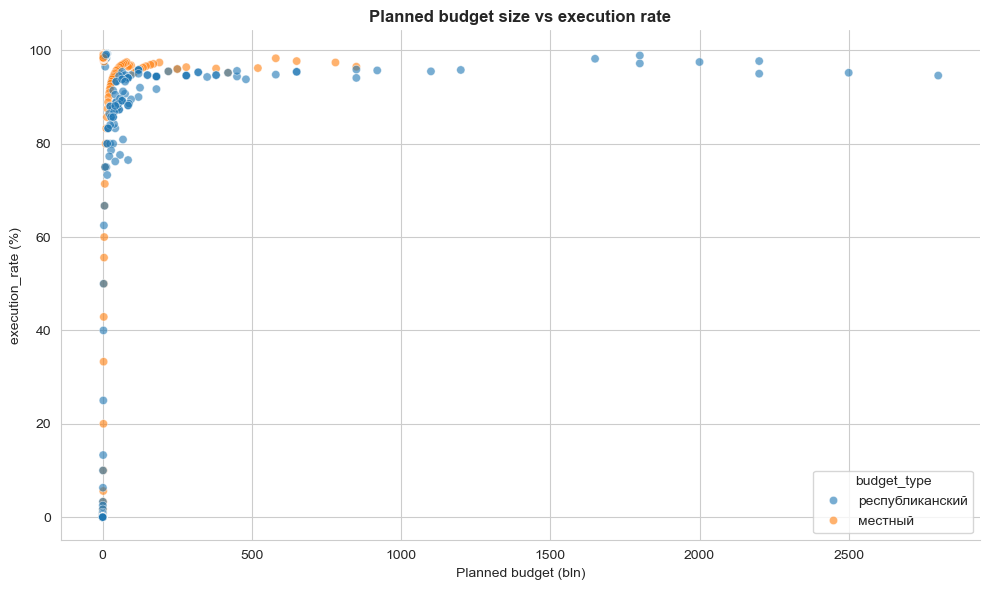

In [340]:
d = df[df['execution_rate'] > 0]
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=d, x='budget_planned_bln', y='execution_rate', hue='budget_type', alpha=0.6, ax=ax)
ax.set_title('Planned budget size vs execution rate', fontweight='bold')
ax.set_xlabel('Planned budget (bln)'); ax.set_ylabel('execution_rate (%)'); sns.despine(); plt.tight_layout(); plt.show()

## Spending over time

> The dataset only has a `year` column (no month/date), so a true month-by-month breakdown is not possible. Yearly is the finest granularity.

In [341]:
year_spend = df.groupby('year')['amount_bln'].sum().to_frame('amount_bln')
year_spend['share_%'] = (year_spend['amount_bln'] / year_spend['amount_bln'].sum() * 100).round(2)
year_spend

,amount_bln,share_%
year,,
2022,1700.00,2.45
2023,4820.00,6.95
2024,15290.32,22.04
2025,29422.55,42.42
2026,8670.00,12.50
2027,9460.00,13.64


##### Chart — spending per year, stacked by budget type

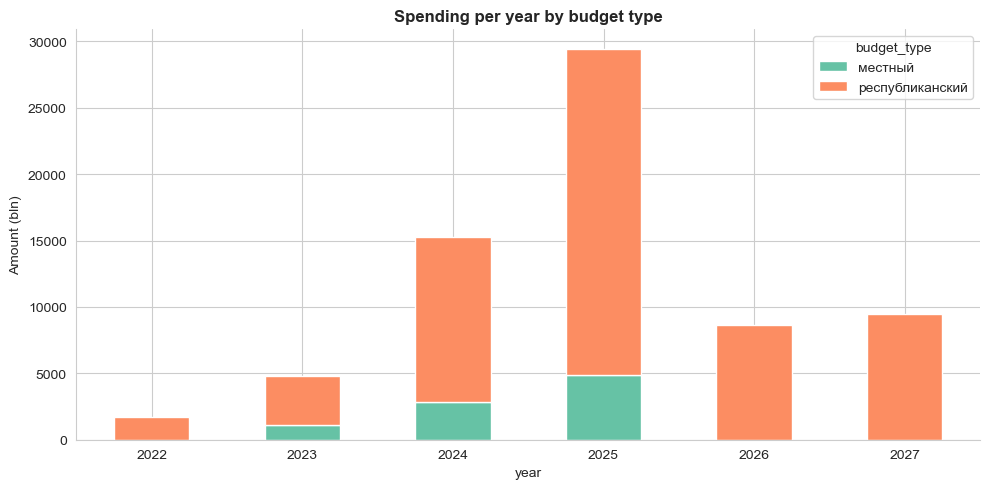

In [342]:
yb = df.pivot_table(index='year', columns='budget_type', values='amount_bln', aggfunc='sum').fillna(0)
ax = yb.plot(kind='bar', stacked=True, figsize=(10, 5), color=sns.color_palette('Set2', yb.shape[1]))
ax.set_title('Spending per year by budget type', fontweight='bold')
ax.set_ylabel('Amount (bln)'); ax.set_xlabel('year'); plt.xticks(rotation=0); sns.despine(); plt.tight_layout(); plt.show()

## Great job! Continue exploring however you like.